In [ ]:
import pandas as pd

meta_table = pd.read_csv('gse40279_meta.csv', delimiter=',')
meta_table.index = ['Age', 'Description', 'GEO']
raw_table = pd.read_csv('GSE40279_average_beta.txt', delimiter='\t', index_col=0)
with open("cd_74_associated_cpgs.txt") as file:
    lines = file.read().splitlines()
cd_74_associated_cpgs_set=set(lines)
#filter for inflammation associated CPG sites
raw_table = raw_table[raw_table.index.isin(cd_74_associated_cpgs_set)] #1293 CPG SITES LEFT
raw_table

,X1001,X1002,X1003,X1004,X1005,X1006,X1007,X1008,X1009,X1010,...,X11085,X11086,X11087,X11089,X11090,X11092,X11093,X11094,X11095,X11096
ID_REF,,,,,,,,,,,,,,,,,,,,,
cg11843502,0.174863,0.199667,0.197990,0.189053,0.203709,0.168005,0.198806,0.170518,0.181513,0.186998,...,0.185103,0.172349,0.167645,0.176240,0.127520,0.180176,0.147239,0.169246,0.163711,0.129589
cg06487986,0.074686,0.065040,0.069715,0.053284,0.062058,0.052559,0.065618,0.065432,0.063987,0.074606,...,0.073007,0.066565,0.068357,0.049509,0.047468,0.064470,0.057758,0.057910,0.053885,0.041685
cg23927002,0.021214,0.036691,0.039626,0.046974,0.037283,0.055979,0.025497,0.034783,0.036062,0.031837,...,0.052336,0.039500,0.043066,0.046578,0.055033,0.055391,0.038604,0.033557,0.055425,0.043548
cg11753033,0.017043,0.016005,0.017115,0.026354,0.030088,0.003177,0.022032,0.013876,0.015035,0.018376,...,0.013547,0.016106,0.005018,0.019529,0.013940,0.005900,0.013367,0.006856,0.000000,0.000000
cg17465881,0.060516,0.079828,0.058642,0.082066,0.068319,0.092545,0.059744,0.056169,0.088278,0.067179,...,0.063336,0.078196,0.073195,0.060206,0.042385,0.064448,0.074746,0.065013,0.060495,0.052780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg16176048,0.022002,0.018104,0.016378,0.020735,0.017148,0.030058,0.018656,0.017493,0.023747,0.023302,...,0.001381,0.003087,0.000000,0.000528,0.000000,0.009722,0.000959,0.000000,0.004542,0.000000
cg27447689,0.050004,0.040150,0.050553,0.049412,0.053590,0.049570,0.048031,0.047594,0.040301,0.051148,...,0.054670,0.062899,0.057988,0.045591,0.037106,0.059920,0.050703,0.045642,0.045757,0.044382
cg21974239,0.067605,0.054013,0.064951,0.061928,0.074344,0.089312,0.070982,0.069145,0.079136,0.066163,...,0.084709,0.077888,0.101311,0.106954,0.082946,0.085487,0.094217,0.089353,0.096273,0.095045


In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np

#ELSO PARAMETER META MASODIK RAW
class MethylationDataset(Dataset):
    def __init__(self, meta_table, raw_table, transform=None):
        self.meta_table = meta_table
        self.raw_table = raw_table
        
    def __len__(self):
        return self.raw_table.shape[1]

    def __getitem__(self, idx):
        # Ensure the index is within the bounds of the meta_table
        if idx >= self.__len__():
            print('Index out of bounds:', idx)
            return -1

        # Extract the RNA data and age
        try:
            rna_data = self.raw_table.iloc[:, idx].tolist()
            age=float(self.meta_table.iloc[0,idx])
        except IndexError as e:
            print(f"IndexError: {e}, idx: {idx}")
            return -1
        return torch.tensor(rna_data), age
    
    def get_features_and_targets(self):
        features = []
        targets = []
        for idx in range(len(self)):
            rna_data, age = self[idx]
            features.append(rna_data.numpy())
            targets.append(age.numpy())
        return np.array(features), np.array(targets)
        

In [6]:
from sklearn.model_selection import train_test_split

#ELSO PARAMETER META MASODIK RAW
transcriptomic_dataset = MethylationDataset(meta_table,raw_table)

train_data, test_data = train_test_split(transcriptomic_dataset, test_size=0.2, random_state=42)

print("Train data size:", len(train_data))
print("Test data size:", len(test_data))

Train data size: 524
Test data size: 132


In [7]:
#ELASTIC NET MODEL
#!pip install scikit-learn

# Initialize lists for features and targets
X_train = []
y_train = []

for features, target in train_data:
    X_train.append(features)
    y_train.append(target)

X_test = []
y_test = []

for features, target in test_data:
    X_test.append(features)
    y_test.append(target)

In [ ]:
import joblib
from sklearn.model_selection import GridSearchCV
from glmnet import ElasticNet
import numpy as np

# Define the model
model = glmnet.ElasticNet(standardize=True)

# Define the parameter grid for alpha
param_grid = {
    'alpha': np.linspace(0.1, 1, 100)  # Test 50 values between 0.0001 and 1
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',  # Use appropriate scoring metric
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all available cores
    verbose=1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Save the best model
best_model = grid_search.best_estimator_
joblib.dump(best_model, "inflammation_glmnet_model_1.pkl")

# Print best alpha and score
print("Best alpha:", grid_search.best_params_['alpha'])
print("Best cross-validation score:", -grid_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best alpha: 0.44545454545454544
Best cross-validation score: 5.870907829601432


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Make predictions on the test data

test_predictions = best_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, test_predictions)
print("TEST Mean Squared Error:", mse)
mae = mean_absolute_error(y_test, test_predictions)
print("Mean Absolute Error:", mae)

from scipy.stats import pearsonr

pearson_r, _ = pearsonr(y_test, test_predictions)
print("Pearson correlation coefficient:", pearson_r)

TEST Mean Squared Error: 75.6022941954222
Mean Absolute Error: 6.815932858168772
Pearson correlation coefficient: 0.8454751818125303


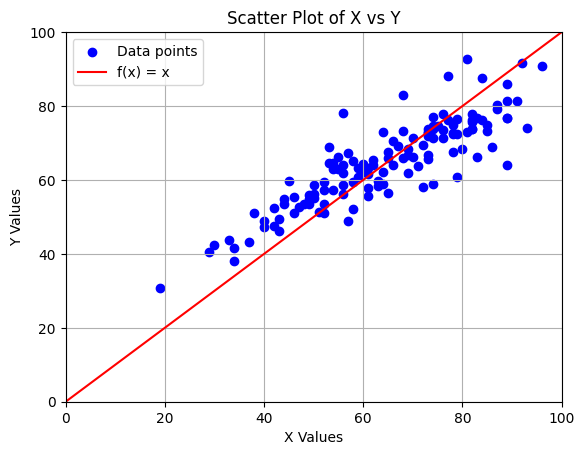

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create scatter plot
plt.scatter(y_test, test_predictions, color='blue', label='Data points')

# Add the f(x) = x line THE REAL AGE THAT THE BLUE DOTS SHOULD CONVERGE TO
x_line = np.linspace(0, 100, 400)
y_line = x_line  # Since f(x) = x
plt.plot(x_line, y_line, color='red', label='f(x) = x')

# Add labels and title
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.title('Scatter Plot of X vs Y')
plt.xlim(0, 100)  # Set the limits for x-axis
plt.ylim(0, 100)  # Set the limits for y-axis
plt.legend()

# Show plot
plt.grid(True)
plt.show()

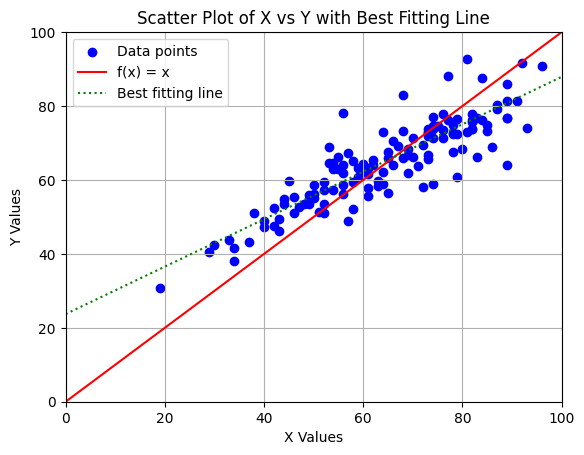

In [ ]:
#Add best fitting line to the plot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

y_test = np.array(y_test)
test_predictions = np.array(test_predictions)

# Reshape y_test for the model (it should be a 2D array)
y_test_reshaped = y_test.reshape(-1, 1)

# Fit linear regression model
model = LinearRegression()
model.fit(y_test_reshaped, test_predictions)

# Generate values for the best fitting line
x_line = np.linspace(0, 100, 400).reshape(-1, 1)
y_line = model.predict(x_line)

# Create scatter plot
plt.scatter(y_test, test_predictions, color='blue', label='Data points')
# Add the f(x) = x line (identity line)
plt.plot(x_line, x_line, color='red', label='f(x) = x')
# Plot the best-fitting line from linear regression
plt.plot(x_line, y_line, color='green', label='Best fitting line', linestyle=':')

# Add labels and title
plt.xlabel('X Values')
plt.ylabel('Y Values')
plt.title('Scatter Plot of X vs Y with Best Fitting Line')
plt.xlim(0, 100)  # Set the limits for x-axis
plt.ylim(0, 100)  # Set the limits for y-axis
plt.legend()

# Show plot
plt.grid(True)
plt.show()